# Tutorial 1: Basics and first contact with Inspect AI

Welcome to the first tutorial.

**What you'll learn:**

- Connect Inspect AI to a language model (locally via Ollama, or via cloud API)
- Run your first evaluation
- Understand how tasks are structured: dataset → solver → scorer
- View and analyze results with `inspect view`
- Create single choice and multiple choice benchmarks
- Analyzing position bias in multiple-choice tasks

**By the end:** You'll have a working evaluation pipeline and understand how to build your own benchmarks.

<details>
<summary>New to Jupyter notebooks? Start here</summary>

A notebook (`.ipynb`) is a series of cells (code and text) that you run one at a time. Code runs in a kernel, a separate Python process that holds your variables while the notebook is open.

How to open and run it:

- VS Code / Cursor: open the `.ipynb`, install the Jupyter extension, then pick a kernel (your virtual environment).
- JupyterLab: run `pip install jupyterlab`, then `jupyter lab` in a terminal.
- Google Colab: upload the file; nothing to install.

To get an environment where every cell below works, run this once in a terminal, then select the `inspect-notebooks` kernel in your editor:

```bash
python -m venv .venv
source .venv/bin/activate      # Windows: .venv\Scripts\activate
pip install -U pip ipykernel
python -m ipykernel install --user --name inspect-notebooks
```

Now `%pip install ...` cells install straight into that environment, so the rest of the notebook runs without surprises.

If you'd rather use `uv` or another tool, you probably already know how to get a working environment, so set it up your way. Just make sure `pip` is available (`uv venv --seed`) if you want the `%pip` cells to work.

</details>

---
## Model setup

Inspect AI doesn't ship a model. You point it at one: a local model through Ollama, or any cloud provider through its API. In section 1.2 you save that choice into a plain Python variable, `MODEL`, and every `eval()` below passes `model=MODEL`. It's just a variable in the kernel, so if you restart the notebook, re-run that cell before running any evaluation.

Two steps:

1. Pick a route from the table below.
2. If that route needs an API key, copy `.env.example` to `.env` and fill in that one key. Inspect loads `.env` automatically, so keys never go into the notebook.

<details>
<summary>How to pick a provider</summary>

Pick one row. Local Ollama is free and needs no key but runs on your own hardware. The cloud routes need a key but no local GPU.

| Route | `MODEL` value | Key in `.env` | Cost | Local hardware | When to use |
|---|---|---|---|---|---|
| Local (Ollama) | `ollama/llama2` | none | free | yes | offline, privacy, no signup |
| OpenRouter | `openrouter/meta-llama/llama-3.1-8b-instruct` | `OPENROUTER_API_KEY` | free tier, then paid | no | no GPU, many models, regional access |
| OpenAI | `openai/gpt-4o-mini` | `OPENAI_API_KEY` | paid | no | you have an OpenAI key |
| OpenAI-compatible | `openai-api/<service>/<model>` | `<SERVICE>_API_KEY` + `<SERVICE>_BASE_URL` | varies | no | any vendor with an OpenAI-style API (DeepSeek, Groq, local vLLM, ...) |
| Perplexity | `perplexity/sonar` | `PERPLEXITY_API_KEY` | paid | no | you already have a key (blocked in your region? use OpenRouter) |

The OpenAI-compatible row is for any vendor that exposes an OpenAI-style API but has no dedicated provider above. Pick a label for `<service>`, then set `<SERVICE>_API_KEY` and `<SERVICE>_BASE_URL` in `.env` to that vendor's key and endpoint. For example, `openai-api/deepseek/deepseek-chat` reads `DEEPSEEK_API_KEY` and `DEEPSEEK_BASE_URL`. Plain `openai/...` always talks to OpenAI itself.

Not sure: use OpenRouter if you have no GPU (browse https://openrouter.ai/models for current free `:free` models), or Ollama if you'd rather stay fully local. Full provider list: [Inspect AI providers](https://inspect.aisi.org.uk/providers.html).

</details>

<details>
<summary>If you chose Ollama: local setup</summary>

Install Ollama once.

**macOS:** `brew install ollama`, or download from https://ollama.ai/download

**Linux:**
```bash
curl -fsSL https://ollama.ai/install.sh | sh
```

**Windows:** download from https://ollama.ai/download

Then start the server and pull a model:
```bash
ollama serve
ollama pull llama2        # or use deepseek-r1:1.5b for a smaller option
```

</details>

---
## Part 1: Basic Inspect setup

### 1.1. Install Inspect AI

In [ ]:
%pip install -q inspect-ai openai
print("✅ Installed: inspect-ai, openai")


### 1.2. Choose your model
Set `MODEL` to the value from the route you picked above. Every `eval()` in this notebook uses it, so this is the only line you change to switch providers.

In [ ]:
MODEL = "ollama/llama2"   # change to your route's value from the table above
print(f"Using model: {MODEL}")

In [ ]:
# Ollama only: confirm the local server is reachable before your first run (skip on a cloud route).
import requests

def check_ollama():
    """Check Ollama connection and show installed models."""
    try:
        response = requests.get("http://localhost:11434/api/tags", timeout=5)
        if response.status_code != 200:
            print("❌ Ollama returned an error")
            return False
            
        models = response.json().get('models', [])
        total_size = sum(m['size'] for m in models)
        
        print("✅ Ollama is running!")
        print(f"\n📊 Installed models: {len(models)} ({total_size / 1e9:.1f} GB total)")
        
        for m in models:
            print(f"   - {m['name']}: {m['size'] / 1e9:.2f} GB")
        
    except requests.exceptions.ConnectionError:
        print("❌ Cannot connect to Ollama")
        print("   Start it with: ollama serve")

check_ollama()

## Assignment 1: 'Hello world' in eval

Let's create the simplest possible evaluation!

**To do:** add one more `Sample()` to the dataset.

In [ ]:
from inspect_ai import Task, task, eval
from inspect_ai.dataset import Sample
from inspect_ai.scorer import exact, match, choice, pattern
from inspect_ai.solver import (
    generate, system_message, chain_of_thought, 
    prompt_template, multiple_choice
)

In [ ]:
@task
def hello_model():
    """Test your model setup with simple questions."""
    return Task(
        dataset=[
            Sample(
                input="Say 'Hello world!' and nothing else.",
                target="Hello world!"
            ),
            Sample(
                input="2+2=",
                target="4"
            ),
            Sample(
                input="What is the surname of Sheldon from The Big Bang Theory?",
                target="Cooper"
            ),
            
            Sample(
                input= # YOUR CODE HERE
                target= # YOUR CODE HERE
            )
        ],
        solver=[generate()],
        scorer= match(
            location="end",        # where to look for the answer: "begin", "end", "any", "exact"
            ignore_case=True,      # ignore case when comparing
            numeric=False          # treat as numeric comparison (normalizes numbers, different punctuation rules)
        )
    )

**Run the evaluation:**

This will take a minute or two depending on your hardware.

In [ ]:
eval(
    hello_model,
    model=MODEL,
    # limit=1  # Uncomment to test with just 1 sample
)

---
## Part 2: Using a cloud API (optional)
No GPU, or want to compare against a hosted model? Switch to a cloud route from the provider table:

1. Put that route's key in `.env` (copy `.env.example` first). For example: `OPENROUTER_API_KEY=sk-or-...`
2. Set `MODEL` in section 1.2 to that route's value, for example `openrouter/meta-llama/llama-3.1-8b-instruct`.
3. Re-run the evaluation above. Same code, different model.

Inspect reads the key from `.env` automatically.

---
## Part 3: Viewing results with Inspect view
Every evaluation saves a log file. `inspect view` opens a web UI to explore them.

### 3.1. Launch Inspect view
1. In terminal, from the notebook's folder, run: `inspect view`
2. Open in browser: http://localhost:7575

This will:
1. Show all evaluation logs in an interactive interface
2. Allow you to drill down into individual samples

**Alternative options:**

```bash
# View logs from a specific directory
inspect view --log-dir ./experiment-logs

# Use a different port
inspect view --port 8080
```

**Troubleshooting:**

- If `inspect: command not found` → try `python -m inspect_ai view`
- If the page won't load → check that you're in the correct folder (logs are saved relative to where you run evaluations)

In [ ]:
# # Uncomment and run this cell if inspect view shows no logs

# import os
# from pathlib import Path
# 
# log_files = list(Path("./logs").glob("*.eval")) if Path("./logs").exists() else []
# 
# if not log_files:
#     print("❌ No log files found")
#     print("   Run at least one eval() in this notebook first")
#     print(f"   Current directory: {os.getcwd()}")
# else:
#     print(f"✅ Found {len(log_files)} log file(s):")
#     for f in sorted(log_files)[-5:]:  # show last 5
#         print(f"   {f.name}")

### Assignment 2: Explore your logs

In the Inspect view UI you can:

- **See overall accuracy** for each evaluation run
- **Click on individual samples** to see the model's response
- **Compare runs** with different models or parameters
- **Filter by metadata** (e.g., show only "hard" problems)
- **Export results** for further analysis

**Tip:** Keep `inspect view` running in a separate terminal while you work through this notebook. It auto-refreshes when new evaluations complete.

---
## Part 4: Understanding benchmark structure
### 4.1. Task components overview
Every Inspect `Task` consists of:

```
Task {
    dataset: [Sample, Sample, ...],    # data to evaluate on
    solver: [Solver, Solver, ...],     # how to process
    scorer: Scorer,                    # how to score
    **parameters                       
}
```

**Basic component flow:**
```
Dataset (Samples) → Solver(s) (using Model) → Scorer → Results
```

**More detailed flow**

The **Task** is defined by its **Dataset**, **Solver(s)**, and **Scorer**. To run a task with `eval()`, you should also provide a **Model**, so that the task is not dependent on a specific model. After the `eval()` run finishes, you will get an **EvalLog**, which you can inspect with `inspect view` (you can also watch it interactively while the evaluation is running). Each complete or partial log is essentially a log file in the `logs/` folder with a name like `2026-02-02T21-12-42-00-00_task_CXmcuyLhaIQtMlWoVgMAIj.eval`. The overall flow is illustrated below:

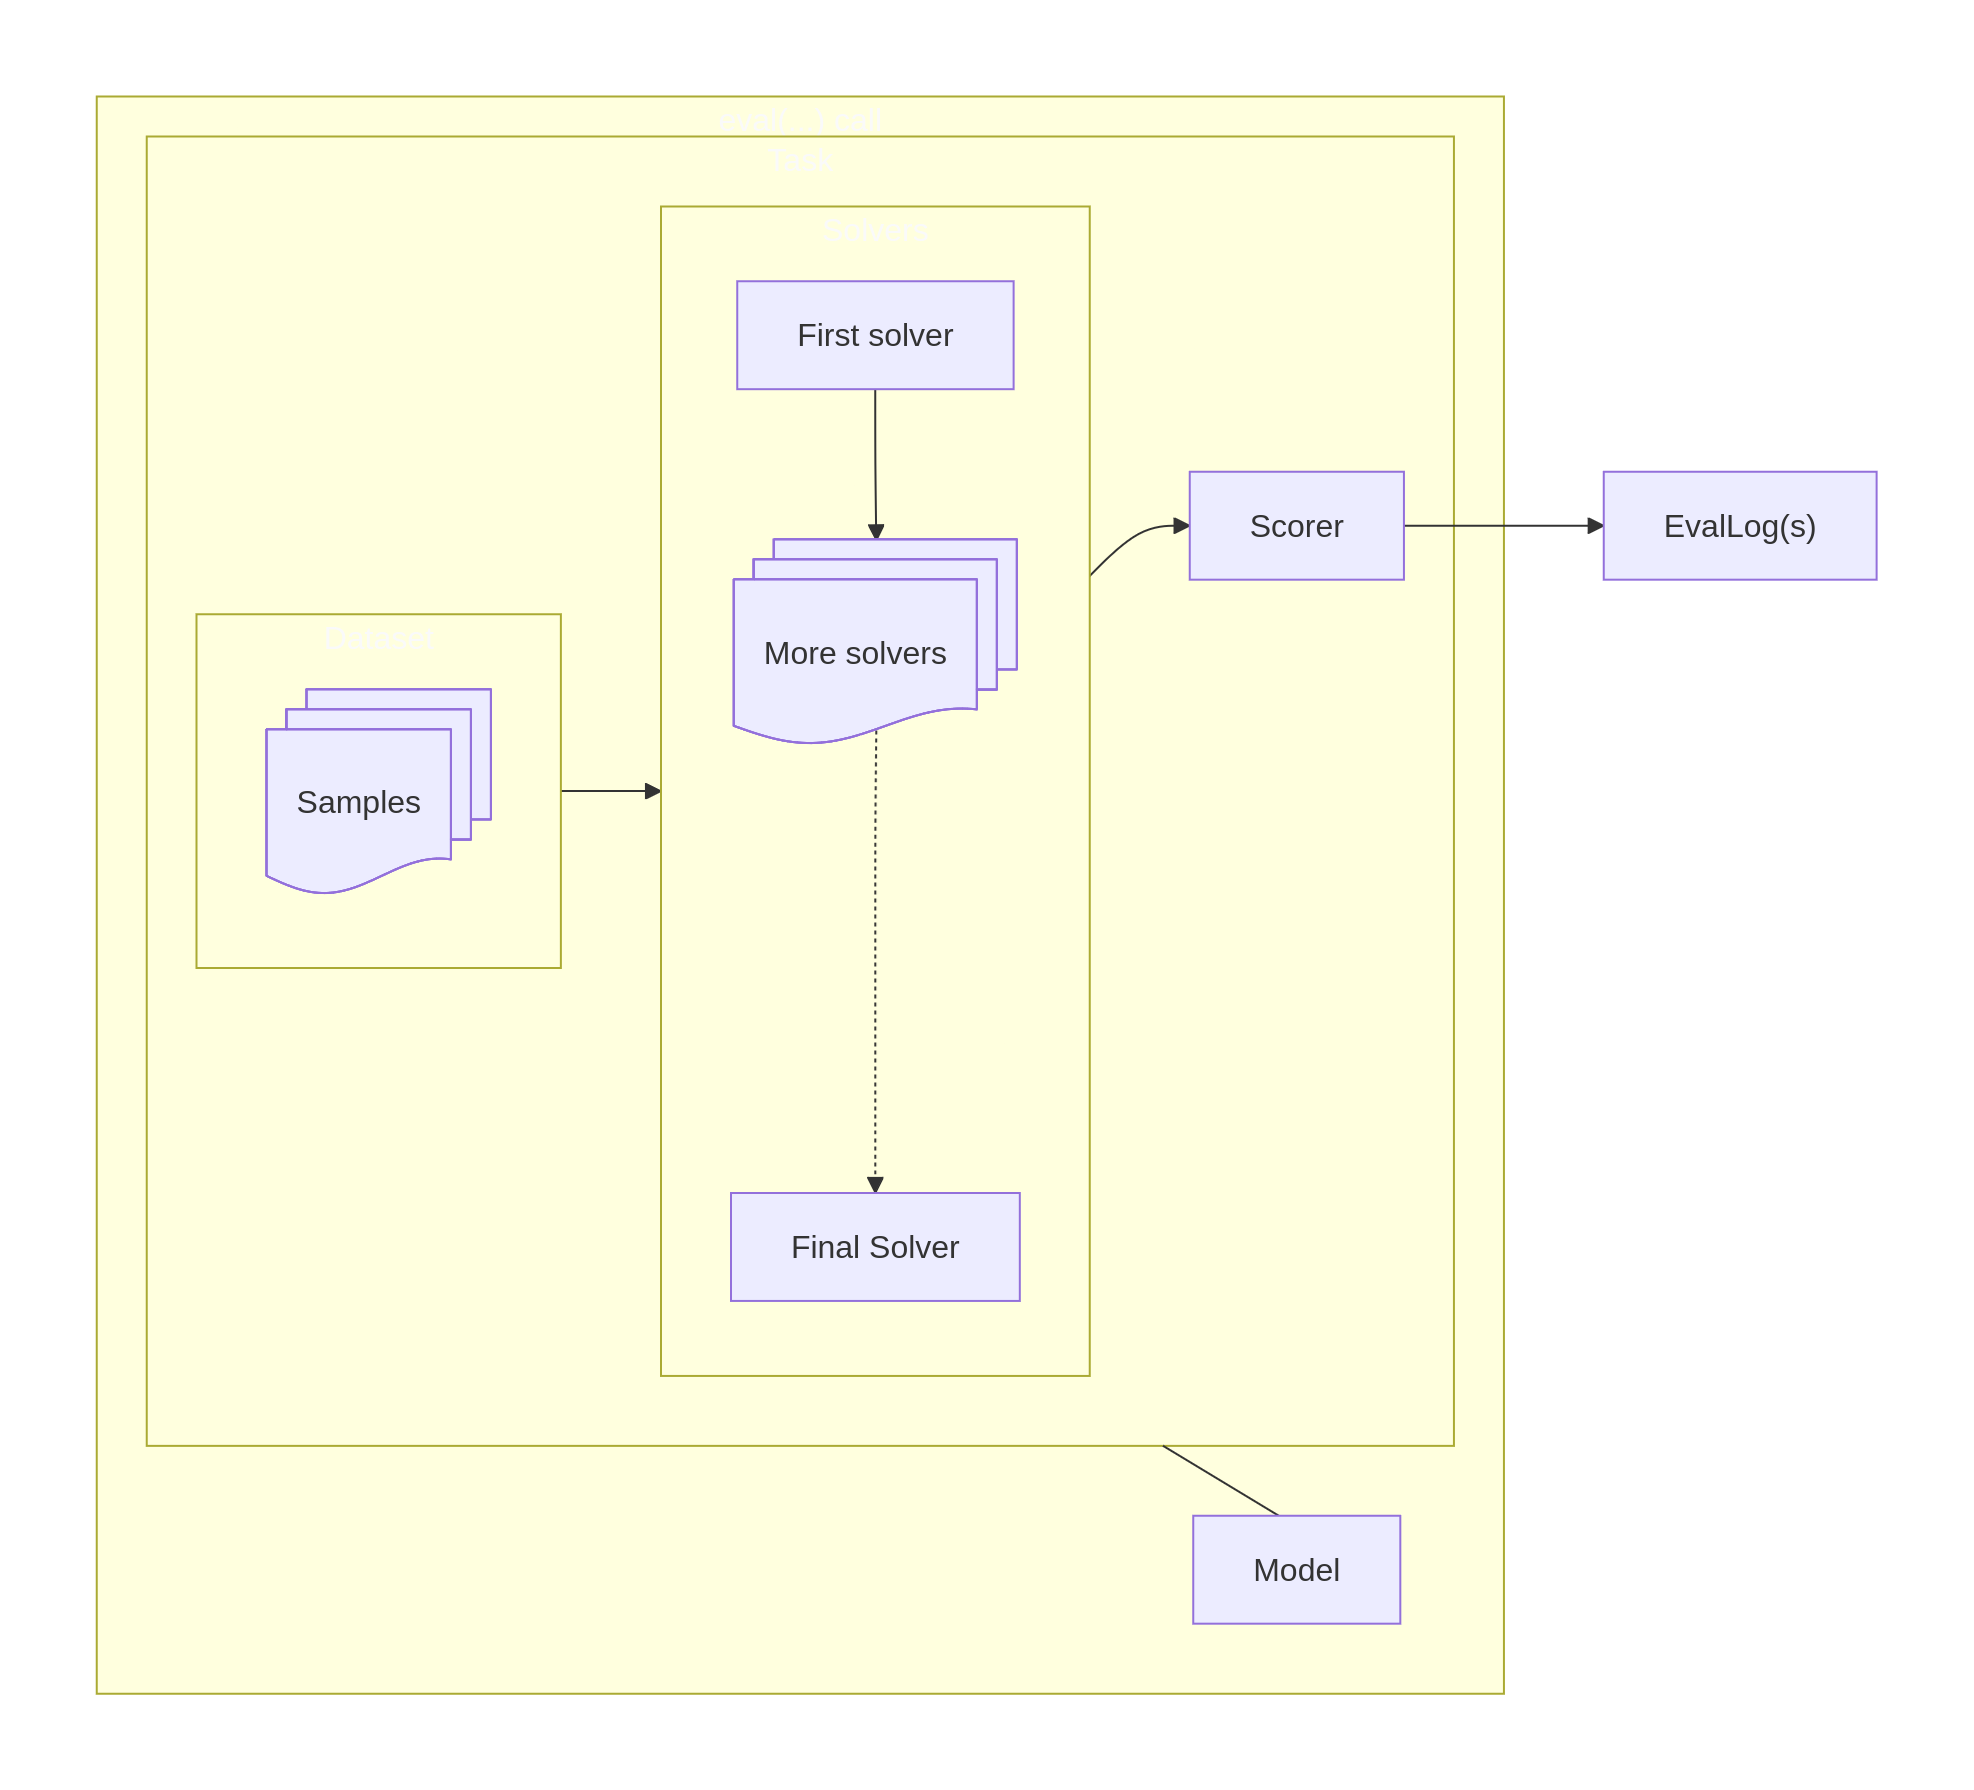

### 4.2. Sample structure
A Sample contains input/target pairs with optional metadata:

In [ ]:
# Example of a fully-featured Sample
sample_example = Sample(
    input="Question or prompt",
    target="Expected answer",
    id="unique_id",
    choices=["Option A", "Option B", "Option C"],  # For multiple choice
    metadata={
        "category": "math",
        "difficulty": "hard"
    }
)

print("Sample components:")
print(f"  - input: {sample_example.input}")
print(f"  - target: {sample_example.target}")
print(f"  - choices: {sample_example.choices}")
print(f"  - metadata: {sample_example.metadata}")

---
## Part 5: Understanding solvers

### 5.1. What is a solver?

A **solver** is a function that transforms a **TaskState** (the prompt + conversation history) into (another) **TaskState** and optionally calls the model to generate a response.

**Think of solvers as middleware that:**
1. Modifies the prompt (prompt engineering)
2. Calls the model (generation)
3. Processes the response (extraction, critique, etc.)

### 5.2. The solver pipeline
Solvers are chained together in a pipeline:

```
Input Sample
    ↓
[Solver 1: system_message]
    ↓
[Solver 2: prompt_template]
    ↓
[Solver 3: chain_of_thought]
    ↓
[Solver 4: generate]
    ↓
Model Output → Scorer → Final Result
```

Each solver receives the TaskState, modifies it, and passes it to the next solver.

### 5.3. TaskState - the core data structure
Every solver operates on a **TaskState** containing:

```
TaskState {
    messages: list[ChatMessage],  # Conversation history
    output: ModelOutput,          # Final model output
    user_prompt: str,             # Current user prompt
    input_text: str,              # Original input
    metadata: dict,               # Sample metadata
    choices: list[str],           # For multiple choice
    model: ModelName,             # Current model
    sample_id: int | str,         # Sample identifier
}
```

---
## Part 6: Built-in solvers
**system_message**
```python
system_message(
    message: str        # REQUIRED - the system prompt
)
```

**prompt_template**
```python
prompt_template(
    template: str       # REQUIRED - use {prompt} as placeholder
)
```

**chain_of_thought**
```python
chain_of_thought(
    template: str = None   # optional - custom CoT prompt (default: "Let's think step by step")
)
```

**generate**
```python
generate(
    max_tokens: int = None,      # optional - limit response length
    temperature: float = None,   # optional - 0.0 = deterministic, 1.0 = creative
    top_p: float = None,         # optional - nucleus sampling
    stop_seqs: list[str] = None  # optional - stop generation at these strings
)
```

**multiple_choice**
```python
multiple_choice(
    cot: bool = False,              # optional - add chain-of-thought
    multiple_correct: bool = False, # optional - allow multiple answers
    shuffle: bool = False           # optional - randomize choice order
)
```

**Typical pipeline:**
```
system_message → prompt_template → chain_of_thought → generate
```

`system_message()` and `prompt_template()` don't run LLM. These solvers can be used to pass prompt parts to the pipeline. Custom prompts can also be set in "generating" (for example, `generate()`, `chain_of_thoughts`) solvers. Think of it as a pipeline that modifies TaskState to get another TaskState, one solver at a time. 

**Note on `multiple_choice()`:** the `multiple_choice()` replaces the chain of solvers (and nothing else) - it handles prompting and generation internally. Also, you can only use `choice()` scorer with the `multiple_choice()` solver. So it will look _exactly_ like this:

```
Input Sample
    ↓
[Solver: multiple_choice]  # only one solver here
    ↓
Model Output → [Scorer: choice()] → Final Result
```

**Note on `multiple_choice(cot=True)` and CoT** To use the `multiple_choice()` with CoT, use `multiple_choice(cot=True)`. You can also directly change template while NOT using `cot` param, using `template` param. For additional help [check docs](https://inspect.aisi.org.uk/reference/inspect_ai.solver.html#multiple_choice).

**Viewing solver execution:** in `inspect view`, click any sample → messages tab shows each solver's contribution.

**(optional) custom solvers note:** (You can write [your own solver](https://inspect.aisi.org.uk/solvers.html#custom-solvers), but it is outside of the scope of this tutorial.)

### 6.1. system_message()

**Purpose:** prepend a system role message to guide model behavior.

**When to use:**
- establish the model's role or persona
- set global guidelines or constraints
- define the evaluation context


In [ ]:
@task
def example_system_message():
    """
    Demonstrates system_message() solver.
    The system prompt tells the model to be concise.
    """
    return Task(
        dataset=[
            Sample(input="What is 15 * 8?", target="120"),
            Sample(input="What is 99 + 1?", target="100"),
        ],
        solver=[
            system_message("You are a calculator. Reply with only the number, nothing else."),
            generate()
        ],
        scorer=match(numeric=True),
    )

# Run and check the Messages tab in inspect view
# NOTE: eval(...) calls on large tasks can be slow.
eval(example_system_message, model=MODEL)

### 6.2. prompt_template()

**Purpose:** substitute variables into a template to reformat prompts.

**When to use:**
- add specific output format requirements
- include examples or demonstrations
- structure prompts consistently
- add reasoning steps or breakdowns


In [ ]:
STEP_BY_STEP_TEMPLATE = '''
Solve this problem step by step:

Problem: {prompt}

Structure:
1. Understand the problem
2. Plan your approach
3. Solve it
4. Final answer format: ANSWER: <value>
'''.strip()

@task
def example_prompt_template():
    """
    Demonstrates prompt_template() solver.
    The template adds structure to the prompt.
    """
    return Task(
        dataset=[
            Sample(input="What is 25 * 4?", target="100"),
            Sample(input="What is 144 / 12?", target="12"),
        ],
        solver=[
            system_message("You are a math tutor."),
            prompt_template(STEP_BY_STEP_TEMPLATE),
            generate()
        ],
        scorer=match(numeric=True),
    )

# Run and see how the template structures the prompt
# NOTE: eval(...) calls on large tasks can be slow.
eval(example_prompt_template, model=MODEL)

### 6.3. chain_of_thought()

**Purpose:** ask the model to "think step by step" before answering.

**When to use:**
- math and logic problems
- multi-step reasoning tasks
- when you want to see the model's thought process

In [ ]:
@task
def example_chain_of_thought():
    """
    Demonstrates chain_of_thought() solver.
    Compare accuracy with and without CoT in inspect view.
    """
    return Task(
        dataset=[
            Sample(
                input="If Alice has 3 apples and Bob gives her 2 more, how many does she have?",
                target="5"
            ),
            Sample(
                input="A train travels 100 km in 2 hours. At this rate, how far in 5 hours?",
                target="250"
            ),
        ],
        solver=[
            system_message("Solve the problem. End with: ANSWER: <number>"),
            chain_of_thought(),
            generate()
        ],
        scorer=match(numeric=True),
    )

eval(example_chain_of_thought, model=MODEL)

### 6.4. multiple_choice()
Special solver for A/B/C/D questions. Handles formatting and answer extraction automatically.

**When to use:**
- multiple choice questions (use instead of generate)
- must have letter target: "A", "B", "C", etc.


**Note 1:** When using `multiple_choice()`, do not use other solvers.

**Note 2:** When using `multiple_choice()`, use `choice()` as the scorer.

**Note 3:** DO NOT stack `chain_of_thought()` + `multiple_choice()`.

In [ ]:
@task
def example_multiple_choice_with_cot():
    """
    Demonstrates multiple_choice(cot=True).
    Model reasons before selecting an answer.
    """
    return Task(
        dataset=[
            Sample(
                input="Light travels faster than sound. If you see lightning and hear thunder 3 seconds later, approximately how far away was the strike?",
                choices=["100 meters", "1 kilometer", "3 kilometers", "10 kilometers"],
                target="B"  # ~1 km (sound travels ~340 m/s)
            ),
        ],
        solver=multiple_choice(cot=True),  # do not add other solvers here
        scorer=choice(),  # do not use other scorers here
    )

eval(example_multiple_choice_with_cot, model=MODEL)

### 6.5 Other solvers
**self_critique()** - Have model refine its own answer
```python
solver=[generate(), self_critique()]
```
<details>
<summary>More about <tt>self_critique()</tt></summary>
    
Self_critique is a solver that introduces two steps: first, an LLM (not necessarily the same model) evaluates the current completion; second, the active LLM takes this critique and generates a response based on the feedback.
</details>
<br>

**use_tools()** - Enable tool/function calling (see tutorial 4 on agents evaluations).
```python
solver=[use_tools(calculator()), generate()]
```

**Custom Solvers** - You can write your own custom solvers and use them. [See docs.](https://inspect.aisi.org.uk/solvers.html#custom-solvers)

---
## Part 7: Single choice tasks
Single choice tasks present the model with limited options to select from.

### 7.1. Simple yes/no classification
The simplest single choice - binary classification:

In [ ]:
@task
def yes_no_classification():
    return Task(
        dataset=[
            Sample(
                input="Is Python a programming language?",
                target="Yes"
            ),
            Sample(
                input="Is water dry?",
                target="No"
            ),
            Sample(
                input="Is the Earth round?",
                target="Yes"
            ),
        ],
        solver=[
            system_message("Answer 'Yes' or 'No'. Be concise."),
            generate()
        ],
        scorer=exact(),
    )

eval(
    yes_no_classification,
    model=MODEL
)

### 7.2. Multi-class classification
In multi-class classification, the model must choose from 3+ categories. This is common for:
- sentiment analysis (positive / negative / neutral)
- topic classification (sports / politics / tech / ...)
- intent detection (question / command / statement)

---

### Task 2: Build a sentiment classifier

**Your goal:** Create a sentiment classification task with at least 4 samples.

**Note:**
- `system_message` defines the classes and output format
- `target` must exactly match one of your class labels

In [ ]:
@task
def sentiment_classification():
    return Task(
        dataset = # YOUR CODE HERE
        solver = # YOUR CODE HERE
        scorer = # YOUR CODE HERE
    )


eval(
    # YOUR CODE HERE
)

### 7.3. Single choice with explanation
Collect both choice and reasoning:

In [ ]:
@task
def choice_with_reasoning():
    PROMPT = '''
Classify as True or False:

Statement: {prompt}

Provide:
1. REASONING: [Your explanation]
2. ANSWER: [True or False]
    '''.strip()

    return Task(
        dataset=[
            Sample(
                input="The Earth is flat.",
                target="False"
            ),
            Sample(
                input="Water boils at 100°C at sea level.",
                target="True"
            ),
        ],
        solver=[
            chain_of_thought(),
            prompt_template(PROMPT),
            generate()
        ],
        scorer=pattern(r'ANSWER:\s*(True|False)'),
    )

eval(choice_with_reasoning, model=MODEL)

---
## Part 8: Multiple choice tasks
### 8.1. Understanding multiple choice in Inspect
Key rules:
- `choices`: list of answer options (no letters — they're added automatically)
- `target`: letter of correct answer ("A", "B", "C", or "D")
- Use `multiple_choice()` solver + `choice()` scorer

### 8.2. Multiple choice with metadata
Metadata lets you filter and analyze results in `inspect view`.

In [ ]:
@task
def mc_with_metadata():
    return Task(
        dataset=[
            Sample(
                input="Capital of Japan?",
                choices=["Seoul", "Tokyo", "Bangkok", "Beijing"],
                target="B",
                metadata={
                    "difficulty": "easy",
                    "category": "geography"
                }
            ),
            Sample(
                input="What is the Heisenberg Uncertainty Principle?",
                choices=[
                    "Cannot know both position and momentum precisely",
                    "Energy cannot be created or destroyed",
                    "All matter has wave-particle duality",
                    "Time always moves forward"
                ],
                target="A",
                metadata={
                    "difficulty": "hard",
                    "category": "physics"
                }
            ),
        ],
        solver=multiple_choice(),
        scorer=choice(),
    )

# Run and check results in inspect view - filter by metadata!
eval(mc_with_metadata, model=MODEL)

### 8.3. Multiple correct Answers
When multiple answers are valid:

In [ ]:
@task
def mc_multiple_correct():
    return Task(
        dataset=[
            Sample(
                input="Which are programming languages?",
                choices=["Python", "HTML", "JavaScript", "CSS"],
                target=["A", "C"]  # Python, JavaScript
            ),
            Sample(
                input="Which continents border the Atlantic Ocean?",
                choices=["Africa", "Asia", "Europe", "South America"],
                target=["A", "C", "D"]  # Africa, Europe, South America
            ),
        ],
        solver=[
            system_message("Select ALL correct answers. You may choose multiple options."),
            multiple_choice(multiple_correct=True)
        ],
        scorer=choice(),
    )

eval(mc_multiple_correct, model=MODEL)

---
## Part 9: Composing solvers together
## Quick reference

| Task type | Solvers | Scorer |
|-----------|---------|--------|
| Simple Q&A | `system_message() + generate()` | `match()` |
| Reasoning | `chain_of_thought() + generate()` | `match()` |
| Structured output | `prompt_template() + generate()` | `pattern()` |
| Classification | `system_message() + generate()` | `exact()` |
| Multiple choice | `multiple_choice()` | `choice()` |
| MC + reasoning | `multiple_choice(cot=True)` | `choice()` |

---
## Assignment 3: Analyzing position bias in multiple choice

Language models can develop **position bias** - a tendency to favor certain answer positions (like more often picking "A" or "C") regardless of content.

In this assignment, you will:
1. Generate a set of simple math questions, with one fixed set of answer options (correct answer + distractors) per question
2. Reuse those same questions and options to build two datasets that differ only in where the correct answer is placed:
   - **Biased:** correct answer is always at position A
   - **Unbiased:** correct answer position is randomized
3. Run evaluations on both and compare results
4. Analyze whether the model shows position bias

Using the same questions and answer options in both runs reduces the influence of confounding factors such as question difficulty or distractor quality, so a noticeable accuracy gap is more likely to reflect position bias. Other factors (sampling noise, model nondeterminism) can still affect it.

⚠️ **Note on methodology:** this is a minimal experiment to get you started. Comparing "all-A" vs "randomized" datasets is a quick sanity check, but it's not the most rigorous way to measure position bias.

Feel free to extend the assignment if you want a deeper analysis!

Remember pipeline:

```
Dataset (Samples) → Solver(s) (using Model) → Scorer → Results
```

<details>
<summary>Remember full pipeline:</summary>

![image.png](attachment:d0884129-fc8f-48cc-abac-09c4b7642b5b.png)
</details>

In [ ]:
import random
from inspect_ai import Task, task, eval
from inspect_ai.dataset import Sample
from inspect_ai.scorer import choice
from inspect_ai.solver import multiple_choice

# For reproducibility
random.seed(42)

### Step 1: Generate questions

First, create a helper function that generates simple questions with known correct answers.

**Function spec:**
- Input: `n` (number of problems to generate)
- Output: list of tuples `(question_text, correct_answer)`
- Example output: `[("What is 5 + 3?", "8"), ("What is 12 - 4?", "8"), ...]`

**This is just an example.** You can implement your own generator with different content - trivia, vocabulary, geography, etc. Just make sure the model can reasonably answer them.

In [ ]:
def generate_questions(n: int) -> list[tuple[str, str]]:
    """
    Generate n simple math problems.

    Args:
        n: number of problems to generate

    Returns:
        List of (question_text, correct_answer) tuples.
        Both elements are strings, e.g. ("What is 5 + 3?", "8").
    """
    problems = []

    for _ in range(n):
        # YOUR CODE HERE
        # Generate a simple math problem (e.g. addition, subtraction,
        # multiplication, powers, modulo, ...).
        # Hint: use random.randint() for the numbers, random.choice() for the operation.
        # Keep the answer a whole number and store it as a string (e.g. str(a + b)),
        # so the numeric distractors in Step 2 work.
        pass

    return problems


# ===== TESTS =====
test_questions = generate_questions(5)

assert len(test_questions) == 5, f"Expected 5 questions, got {len(test_questions)}"
assert all(isinstance(q, tuple) and len(q) == 2 for q in test_questions), "Each question must be a tuple of (question_text, answer)"
assert all(isinstance(q[0], str) and isinstance(q[1], str) for q in test_questions), "Both question and answer must be strings"
assert all(len(q[0]) > 0 and len(q[1]) > 0 for q in test_questions), "Question and answer cannot be empty"

print("\nSample output:")
for q, a in test_questions:
    print(f"  {q} → {a}")

### Step 2: Create wrong answers (distractors)

For multiple choice, we need plausible wrong answers.

**Function spec:**
- Input: `correct` (str) — the correct answer
- Output: list of 3 wrong answers (str), all different from the correct answer and from each other

**Tip:** generate distractors close to the correct answer (e.g., ±1, ±2, ±10) to make them plausible.

In [ ]:
def generate_distractors(correct: str, n: int = 3) -> list[str]:
    """
    Generate n plausible wrong answers.
    
    For numeric answers: generates nearby numbers.
    For other types: you'll need to customize this.
    
    Args:
        correct: the correct answer (string)
        n: number of distractors to generate
        
    Returns:
        List of n distinct wrong answers (strings)
    """
    distractors = set()

    offsets = # YOUR CODE HERE

    while len(distractors) < n:
    
        # YOUR CODE HERE
        # Generate offsets and find wrong answers that are close to correct but not equal
        pass
        
    return list(distractors)

# ===== TESTS =====
test_distractors = generate_distractors("10", n=3)

assert len(test_distractors) == 3, f"Expected 3 distractors, got {len(test_distractors)}"
assert all(isinstance(d, str) for d in test_distractors), "All distractors must be strings"
assert "10" not in test_distractors, "Distractors must not include the correct answer"
assert len(set(test_distractors)) == 3, "All distractors must be unique"

print(f"   Distractors for '10': {test_distractors}")

### Step 3: Place the correct answer (build the samples)

Now turn each question into a multiple-choice `Sample`.

By this point the answer options are already fixed — the correct answer plus its distractors. This function has only one job: decide where the correct answer sits among those options.

**Function spec:**
- Input:
  - `pool` - list of `(question_text, correct, distractors)` tuples (the frozen content)
  - `correct_position` - where to place the correct answer:
    - `None` → randomize position for each question
    - `0` → always position A
    - `1` → always position B
    - `2` → always position C
    - `3` → always position D
- Output:
    - list of `Sample` objects

⚠️ **Note on `Sample` type:**

`Sample` is an Inspect AI class. For multiple choice, you create it like this:
```python
Sample(
    input="What is 2 + 2?",           # question text
    choices=["3", "4", "5", "6"],     # list of options: list[str]
    target="B"                         # letter of correct answer (A/B/C/D)
)
```

In [ ]:
def create_samples(
    pool: list[tuple[str, str, list[str]]],
    correct_position: int | None = None,
) -> list[Sample]:
    """
    Convert frozen (question, correct, distractors) triples into
    multiple-choice Samples.

    In every case the distractors are shuffled into the remaining free
    positions, so their order never encodes anything. Only the correct
    answer's position is controlled:
        correct_position:
            None → correct answer at a random position (A/B/C/D) per question
            0 → correct answer always at position A
            1 → correct answer always at position B
            2 → correct answer always at position C
            3 → correct answer always at position D

    Args:
        pool: list of (question_text, correct, distractors) tuples.
            The options are already fixed — this function only decides
            where the correct answer goes.
        correct_position: see above.

    Returns:
        List of Sample objects ready for Inspect AI.
        Each Sample has:
            - input: str (the question)
            - choices: list[str] (4 options, no letters)
            - target: str (correct letter: "A", "B", "C", or "D")
    """
    samples = []

    for question, correct, distractors in pool:

        # YOUR CODE HERE

        # 1. Shuffle the distractors, so they fill the remaining positions in a
        #    random order. Do this in both cases — otherwise, with a fixed
        #    correct_position, the distractors would always land in the same
        #    slots and their order could become its own source of bias.
        # 2. Pick the index for the correct answer:
        #    - If correct_position is None → a random index (0..3).
        #    - Otherwise → correct_position.
        # 3. Insert `correct` at that index among the shuffled distractors.
        # 4. Work out the target letter from that index. Hint: "ABCD"[index].
        # 5. Create Sample(input=..., choices=..., target=...) and append it.
        pass

    return samples


# ===== TESTS =====
# Frozen pool: (question, correct, distractors).
test_pool = [
    ("What is 2 + 2?", "4", ["3", "5", "6"]),
    ("What is 10 - 3?", "7", ["6", "8", "9"]),
    ("What is 5 + 5?", "10", ["9", "11", "12"]),
]
samples_fixed = create_samples(test_pool, correct_position=0)
samples_random = create_samples(test_pool, correct_position=None)

assert len(samples_fixed) == len(test_pool), f"Expected {len(test_pool)} samples, got {len(samples_fixed)}"
assert all(hasattr(s, 'input') and hasattr(s, 'choices') and hasattr(s, 'target') for s in samples_fixed), "Each sample must have 'input', 'choices', and 'target' attributes"
assert all(len(s.choices) == 4 for s in samples_fixed), "Each sample must have exactly 4 choices"
assert all(s.target == "A" for s in samples_fixed), "With correct_position=0, all targets should be 'A'"
assert all(s.choices[0] == correct for s, (_, correct, _) in zip(samples_fixed, test_pool)), "With correct_position=0, correct answer should be first in choices"
assert all(s.target in {"A", "B", "C", "D"} for s in samples_random), "Target must be exactly one of A, B, C, D"

# Correct answer must sit at the target position, and the options must be
# exactly the correct answer plus its distractors.
for s, (_, correct, distractors) in zip(samples_random, test_pool):
    target_index = "ABCD".index(s.target)
    assert s.choices[target_index] == correct, f"Correct answer '{correct}' should be at position {s.target}, but found '{s.choices[target_index]}'"
    assert set(s.choices) == {correct, *distractors}, "Options must be exactly the correct answer plus its distractors"

print("✅ create_samples tests passed")

### Step 4: Wrap the samples in a Task

Wrap a ready list of `Sample`s into an Inspect `Task`.


**Hint:** this is a multiple-choice task, so use the standard pair from the Quick reference table in Part 10 — `multiple_choice()` as the solver and `choice()` as the scorer.

In [ ]:
@task
def position_bias_task(samples: list[Sample]):
    """
    Multiple choice evaluation task.

    Args:
        samples: multiple-choice Samples (built in Step 5).
    """
    return Task(
        dataset=samples,
        solver = # YOUR CODE HERE
        scorer = # YOUR CODE HERE
    )

### Step 5: Build the dataset once, then run both evaluations

Generate the questions and their distractors only once — this freezes the content. Then derive the two datasets from that same content by changing only the position of the correct answer:

1. **Biased:** correct answer always at position A
2. **Unbiased:** correct answer position randomized

The only thing that changes between the two runs is where the correct answer is.

**Note:** if you regenerated the distractors for each run instead, you'd be comparing two different datasets and couldn't tell position effects apart from content effects.

In [ ]:
# MODEL is the one you chose in section 1.2.
N_QUESTIONS = # YOUR CODE HERE

random.seed(42)
questions = generate_questions(N_QUESTIONS)

# Each question keeps the same correct answer and the
# same distractors across both runs. This is the (question, correct, distractors) pool.
pool = [(question, correct, generate_distractors(correct)) for question, correct in questions]

# Two views of the same content — they differ only in the correct answer's position.
samples_biased = create_samples(pool, correct_position=0)       # correct always at A
samples_unbiased = create_samples(pool, correct_position=None)  # correct at a random position

# Biased run: correct answer is always "A"
eval(position_bias_task(samples_biased), model=MODEL)

# Unbiased run: correct answer position is randomized
eval(position_bias_task(samples_unbiased), model=MODEL)

### Step 6: Analyze your results

Open `inspect view` and examine both evaluation runs.

1. **Accuracy comparison:**
   - Biased task accuracy: ____%
   - Unbiased task accuracy: ____%
  
2. **Your analysis**
    - What do the numbers show? (just the facts)
    - What patterns do you notice?
    - What might explain them? What doesn't fit your explanation?
    - What else did you try, and what did you learn?
   
       etc.

### Free experimentation: other positions

`create_samples` can also force the correct answer to B, C or D (`correct_position=1`, `2`, or `3`), not just A. You're welcome to try these to probe each position on its own.

⚠️ **Note on multiple testing:** the core assignment makes a single comparison (random vs. A). Once you test several positions at once (A vs. B vs. C vs. D), the chance that at least one looks "biased" by luck grows with every extra comparison. So a single off-looking position is weak evidence on its own: to claim a real per-position effect you generally need a larger sample and a correction for the number of comparisons (e.g. Bonferroni). That is why the core assignment stays at one comparison.

### Bonus challenges (optional)

If you want to explore further:

1. **Try different models** - Do all models show the same bias pattern?

2. **Add Chain-of-Thought** - Does `multiple_choice(cot=True)` reduce position bias?

3. **More positions** - What if you have 5 or 6 choices instead of 4?

4. **Statistical test** - Is the position preference statistically significant? (Chi-squared test)

5. **Content factors** - What else might affect position bias?